# Singular value decomposition in NumPy


In [1]:
# In NumPy, SVD can be easily performed using the svd()function. Here is an example.

In [2]:
import numpy as np
A = np.array([[2, 4, 1],
              [5, 7, 6],
              [1, 1, 3]])

U, s, Vt = np.linalg.svd(A)

print("A")
print(A)
print("nU")
print(U)
print("ns")
print(s)
print("nVt")
print(Vt)

A
[[2 4 1]
 [5 7 6]
 [1 1 3]]
nU
[[-0.36355001 -0.70541344 -0.60845974]
 [-0.89950704  0.09591726  0.42624754]
 [-0.24231895  0.70227612 -0.66939508]]
ns
[11.65611521  2.46114006  0.27886873]
nVt
[[-0.46902026 -0.68574033 -0.55657901]
 [-0.09303187 -0.58832768  0.80325315]
 [ 0.87827391 -0.42852158 -0.2121419 ]]


# First: The SVD Equation
For any matrix A, SVD says:
A=UΣVT

Where:
U = left singular vectors (orthonormal matrix)
Σ = singular values (diagonal matrix)
Vᵀ = right singular vectors (orthonormal matrix)

Shape breakdown for 3×3 A:

| Matrix | Shape | Meaning                              |
| ------ | ----- | ------------------------------------ |
| U      | 3×3   | directions in **row-space**          |
| Σ      | 3×3   | singular values (stretching factors) |
| Vᵀ     | 3×3   | directions in **column-space**       |


##  1. U — Left Singular Vectors
U
[[-0.36355    -0.70541    -0.60846 ]
 [-0.899507    0.095917    0.426247]
 [-0.242319    0.702276   -0.669395]]

 These are orthonormal vectors. 
Meaning:
each column in U is a unit vector
columns are perpendicular
What U represents?
U gives directions in the output space (also called left space or row space).
Geometric meaning:
U rotates the coordinate system of the rows of A.
In PCA terms:
U contains the coordinates of the data projected onto the principal directions.

## 2. s (singular values)
s = [11.65611521  2.46114006  0.27886873]
These are NOT the diagonal matrix Σ yet.
NumPy returns only diagonal entries.

To form Σ:
Σ= [[11.656 0 0]
[0 2.461 0]
[0 0 0.2789]]

**Meaning:**
- These values tell how much A stretches vectors along each singular direction.
- Large singular values = important directions
- Tiny singular values = almost no information
- This is why PCA uses largest singular values.

## 3. Vᵀ — Right Singular Vectors
Vt
[[-0.46902026 -0.68574033 -0.55657901]
 [-0.09303187 -0.58832768  0.80325315]
 [ 0.87827391 -0.42852158 -0.2121419 ]]
Vᵀ is orthonormal.
The rows of Vᵀ (or columns of V) are principal directions in the input space.
Meaning : - V contains the principal components (directions of maximum variance).
So:

- V[:,0] = most important direction
- V[:,1] = second direction
- V[:,2] = least important
- This is the SAME as eigenvectors of AᵀA.
INAL INTUITIVE SUMMARY
🔹 U (Left singular vectors)

Describe output space

Orthonormal rotation of row space

Length m × m (3×3 here)

🔹 Σ (Singular values)

Measure strength of each direction

Larger = more important

Used in PCA to rank components

🔹 Vᵀ (Right singular vectors)

Describe input space

Columns of V = principal components

Eigenvectors of AᵀA

# PART 1 — Eigen Decomposition

Eigen decomposition applies to square symmetric matrices, e.g.:

Covariance matrix : - 𝐶=𝑋𝑇𝑋
- Correlation matrix
- Real symmetric matrices
Formula Cv = λv
v = eigenvector (direction)
λ = eigenvalue (how much variance in that direction)
This means:

When you multiply the matrix by the eigenvector, it only stretches it (scales it), does not change its direction.

For a covariance matrix:
eigenvectors = principal axes (principal components)
eigenvalues = variance along those axes

Eigen-decomposition: C=VΛVT
Where:
V = matrix of eigenvectors
Λ = diagonal matrix of eigenvalues

# PART 2 — Singular Value Decomposition (SVD)
- SVD works for ANY matrix, not only square ones.
If X is m * n (m samples , n features ):

  X=UΣVT

Where: 
- U = m×m matrix (left singular vectors)
- Σ = diagonal matrix of singular values
- V = n×n matrix (right singular vectors)
- Meaning:

- Columns of V = directions in feature space
- ✔ these are principal components

- Diagonal of Σ contains singular values
 -✔ related to variance

- U gives coordinates of data in PC space (scores)

# Eigendecomposition in NumPy


In [ ]:
# # Eigendecomposition is the process of decomposing a square matrix A into the product of eigenvalues and eigenvectors as in the following equation.

# A: The matrix on which we perform eigendecomposition. It should be a square matrix.
# λ: A scalar called the eigenvalue.
# x: A vector called the eigenvector.


In [3]:
import numpy as np
A = np.array([[2, 4, 1],
              [5, 7, 6],
              [1, 1, 3]])

eigen_vals, eigen_vecs = np.linalg.eig(A)

print("A")
print(A)
print("nEigenvalues")
print(eigen_vals)
print("nEigenvectors")
print(eigen_vecs)
# Each column is an eigenvector.

A
[[2 4 1]
 [5 7 6]
 [1 1 3]]
nEigenvalues
[10.60933259 -0.41711497  1.80778238]
nEigenvectors
[[ 0.43145854  0.86258552 -0.69629596]
 [ 0.88537863 -0.49429774 -0.14241114]
 [ 0.17305554 -0.1077774   0.7034849 ]]


In [ ]:
# NumPy’s eig() function returns eigenvalues as a vector. That vector contains all the eigenvalues of A.

# We’ve performed both SVD and eigendecomposition on the same matrix, A. By looking at the outputs, we can say that:

# Singular value decomposition and the eigendecomposition are not the same things even if the matrix is square.

# Performing PCA using singular value decomposition

In [4]:
# PCA is often performed by applying SVD to the covariance matrix of standardized data. The covariance matrix of standardized data is exactly the same as the correlation matrix of non-standardized data.

# We standardize data before SVD because singular values are highly sensitive to the relative ranges of original features.

# # To demonstrate the PCA process using SVD, we’ll use the Wine dataset which has 13 input features.

In [11]:
# step 1 : 
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

print("Wine dataset size",X.shape)

Wine dataset size (178, 13)


In [6]:
# Step2 : Standardsize the data
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

In [7]:
# Step 3 : computing the covariance matrix of standardized data
import numpy as np
cov_mat = np.cov(X_scaled.T)

In [9]:
# Step4 :
# Performing the SVD on the covariance matrix and getting the singular values of the covariance matrix
U , s , Vt = np.linalg.svd(cov_mat)
print(s)

[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868 0.64528221
 0.55414147 0.35046627 0.29051203 0.25232001 0.22706428 0.16972374
 0.10396199]


Dataset Shape: (178, 13)

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


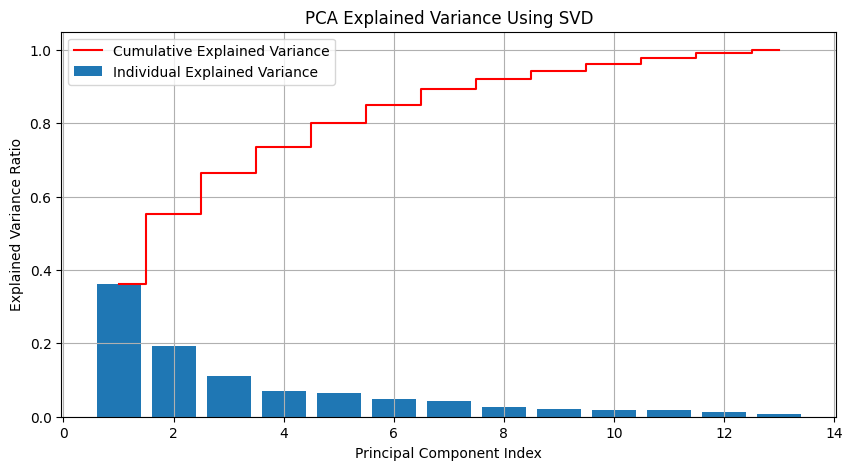


Reduced Data Shape: (178, 7)


In [12]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load Data
# ------------------------------
wine = load_wine()
X = wine.data
y = wine.target
m, n = X.shape

print("Dataset Shape:", X.shape)

# ------------------------------
# 2. Standardize the Data
# ------------------------------
X_scaled = StandardScaler().fit_transform(X)

# ------------------------------
# 3. Perform SVD on centered data
# ------------------------------
# SVD of X_scaled
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
# Shapes:
# U : m x m
# S : min(m,n)
# Vt: n x n

# ------------------------------
# 4. Compute Explained Variance
# ------------------------------
explained_variance = (S**2) / (m - 1)    # same as eigenvalues of covariance matrix
total_variance = explained_variance.sum()
explained_variance_ratio = explained_variance / total_variance

print("\nExplained Variance Ratio:")
print(explained_variance_ratio)

# ------------------------------
# 5. Cumulative Variance for Choosing Number of PCs
# ------------------------------
cum_var = np.cumsum(explained_variance_ratio)

# ------------------------------
# 6. Plot Explained Variance
# ------------------------------
plt.figure(figsize=(10, 5))
plt.bar(range(1, n+1), explained_variance_ratio, label="Individual Explained Variance")
plt.step(range(1, n+1), cum_var, where="mid", color="red", label="Cumulative Explained Variance")
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Using SVD")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# 7. Reduce Data Using k Components (example: k=7)
# ------------------------------
k = 7
V_k = Vt[:k]               # first k principal components
X_reduced = X_scaled @ V_k.T

print("\nReduced Data Shape:", X_reduced.shape)


Dataset Shape: (178, 13)

Eigenvalues:
[4.73243698 2.51108093 1.45424187 0.92416587 0.85804868 0.64528221
 0.55414147 0.35046627 0.29051203 0.25232001 0.22706428 0.16972374
 0.10396199]

Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


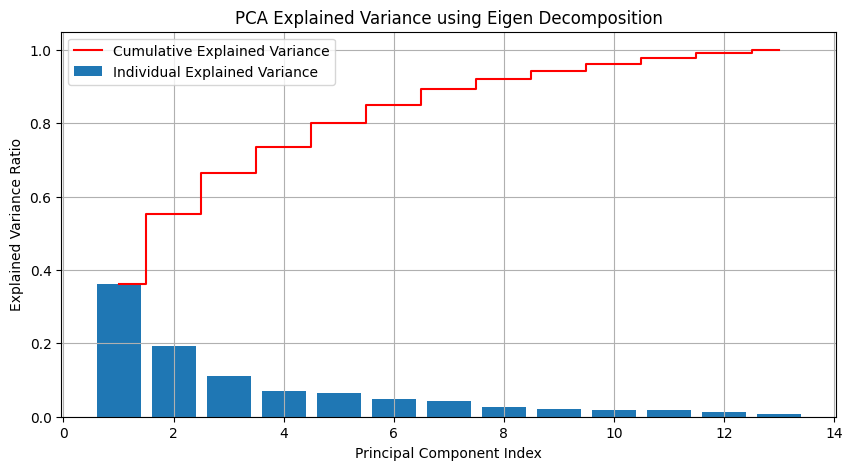


Reduced Data Shape: (178, 7)


In [13]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load Data
# ------------------------------
wine = load_wine()
X = wine.data
y = wine.target
m, n = X.shape

print("Dataset Shape:", X.shape)

# ------------------------------
# 2. Standardize the Data
# ------------------------------
X_scaled = StandardScaler().fit_transform(X)

# ------------------------------
# 3. Compute Covariance Matrix
# ------------------------------
cov_mat = np.cov(X_scaled.T)     # shape (n, n)

# ------------------------------
# 4. Eigen Decomposition
# ------------------------------
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# ------------------------------
# 5. Sort Eigenvalues (descending order)
# ------------------------------
sorted_idx = np.argsort(eigen_vals)[::-1]

eigen_vals = eigen_vals[sorted_idx]
eigen_vecs = eigen_vecs[:, sorted_idx]   # keep eigenvectors sorted too

print("\nEigenvalues:")
print(eigen_vals)

# ------------------------------
# 6. Explained Variance
# ------------------------------
total_var = eigen_vals.sum()

explained_variance_ratio = eigen_vals / total_var
cum_var = np.cumsum(explained_variance_ratio)

print("\nExplained Variance Ratio:")
print(explained_variance_ratio)

# ------------------------------
# 7. Plot Explained + Cumulative Variance
# ------------------------------
plt.figure(figsize=(10, 5))
plt.bar(range(1, n+1), explained_variance_ratio, label='Individual Explained Variance')
plt.step(range(1, n+1), cum_var, where='mid', color='red', label='Cumulative Explained Variance')
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance using Eigen Decomposition")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# 8. Reduce data using first k eigenvectors
# ------------------------------
k = 7     # for example, first 7 PCs capture ~90%
W = eigen_vecs[:, :k]   # n × k eigenvector matrix

X_reduced = X_scaled @ W

print("\nReduced Data Shape:", X_reduced.shape)
